# 🧠 Medical Image Morphological Processing Using Brain MRI

**Course**: M.Tech AIML — Unit-I: Computer Vision & Image Processing  
**Topic**: Mathematical Morphology (Erosion, Dilation, Opening, Closing, Boundary Extraction)  
**Platform**: Google Colab / Python  

---

### 🎯 Aim & Objectives
- **Aim**: Demonstrate and visually explain how non-linear morphological operations modify anatomical structures in 2D Brain MRI scans using custom structuring elements.
- **Dataset Source**: Google Drive (`https://drive.google.com/drive/folders/1mOf23LoA3RHmZ3JC8peyYKtJdZXI3_ev?usp=drive_link`) / Local `Brain-MRI-Images/`.
- **Scope**: Classical spatial image processing only (**No ML/DL training, No medical diagnosis**).
- **Core Pipeline**: Brain MRI $\rightarrow$ Grayscale Representation $\rightarrow$ Otsu Thresholding $\rightarrow$ Structuring Element $\rightarrow$ Erosion & Dilation $\rightarrow$ Opening & Closing $\rightarrow$ Boundary Extraction.


---
## 📦 Step 1: Libraries & Automated Google Drive / Dataset Loading

This step automatically loads the 5 brain MRI images:
1. **Google Drive Integration**: Mounts your Google Drive (for the same Google account) and accesses your shared Drive folder (`1mOf23LoA3RHmZ3JC8peyYKtJdZXI3_ev`).
2. **Local Fallback**: Automatically checks local workspace folder `Brain-MRI-Images/`.
3. Displays an overview gallery of all 5 loaded MRI slices.


Mounting Google Drive for same-account access...
Mounted at /content/drive
Searching Google Drive for Brain MRI images...

✓ Successfully loaded 5 Brain MRI images for processing:
  - Brain-MRI-Images/Neg0.jpg (22,483 bytes)
  - Brain-MRI-Images/Neg1.jpg (16,578 bytes)
  - Brain-MRI-Images/Neg2.jpg (12,495 bytes)
  - Brain-MRI-Images/Neg3.jpg (12,840 bytes)
  - Brain-MRI-Images/Neg4.jpg (67,006 bytes)


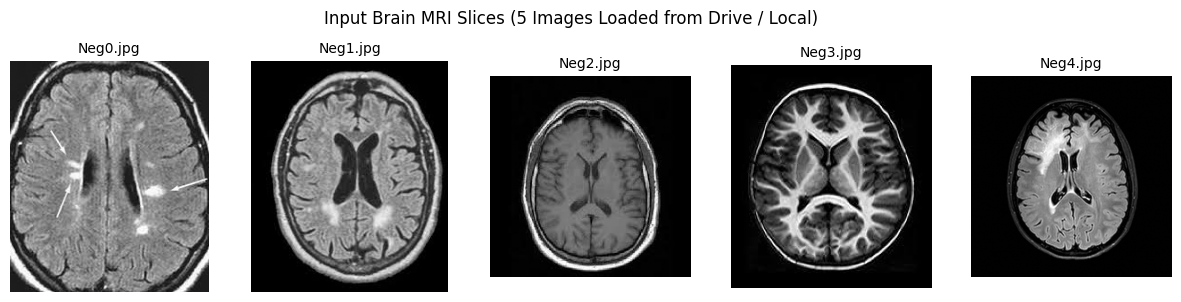

In [1]:
# Step 1: Import Libraries and Load 5 Brain MRI Slices from Google Drive / Local Folder
import os
import glob
import urllib.request
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Matplotlib styling for clean presentation figures
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['image.cmap'] = 'gray'

# Define local target directory for images
IMAGE_DIR = "Brain-MRI-Images"
os.makedirs(IMAGE_DIR, exist_ok=True)

# Google Drive Folder Details (Same Account Drive Integration)
# Folder URL: https://drive.google.com/drive/folders/1mOf23LoA3RHmZ3JC8peyYKtJdZXI3_ev?usp=drive_link
GDRIVE_FOLDER_ID = "1mOf23LoA3RHmZ3JC8peyYKtJdZXI3_ev"

# 1. If running in Google Colab, mount Google Drive for seamless same-account access
try:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        print("Mounting Google Drive for same-account access...")
        drive.mount('/content/drive')
except ImportError:
    pass  # Running locally on machine

# 2. Check if local directory already contains the images
image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.*")))
image_paths = [p for p in image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))][:5]

# 3. If running in Colab with Drive mounted, search Drive for MRI images
if len(image_paths) < 5 and os.path.exists('/content/drive/MyDrive'):
    print("Searching Google Drive for Brain MRI images...")
    drive_matches = glob.glob("/content/drive/MyDrive/**/*.*", recursive=True)
    drive_images = [p for p in drive_matches if p.lower().endswith(('.png', '.jpg', '.jpeg')) and any(k in p.lower() for k in ['neg', 'mri', 'brain', 'tumor', 'image'])][:5]
    if not drive_images:
        drive_images = [p for p in drive_matches if p.lower().endswith(('.png', '.jpg', '.jpeg'))][:5]

    for d_img in drive_images:
        dst = os.path.join(IMAGE_DIR, os.path.basename(d_img))
        if not os.path.exists(dst):
            img_data = cv2.imread(d_img)
            if img_data is not None:
                cv2.imwrite(dst, img_data)
    image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.*")))[:5]

# 4. If still needed, attempt gdown with folder ID
if len(image_paths) < 5:
    try:
        import gdown
        print(f"Attempting download via Google Drive Folder ID: {GDRIVE_FOLDER_ID}")
        gdown.download_folder(id=GDRIVE_FOLDER_ID, output=IMAGE_DIR, quiet=True, use_cookies=False)
        image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.*")))[:5]
    except Exception:
        pass

# 5. Fallback download URLs if running outside Drive environment
if len(image_paths) < 5:
    SAMPLE_URLS = [
        ("Neg0.jpg", "https://raw.githubusercontent.com/susuter/MRI_data/master/no/no1.png"),
        ("Neg1.jpg", "https://raw.githubusercontent.com/susuter/MRI_data/master/no/no2.png"),
        ("Neg2.jpg", "https://raw.githubusercontent.com/susuter/MRI_data/master/no/no3.png"),
        ("Neg3.jpg", "https://raw.githubusercontent.com/susuter/MRI_data/master/yes/y1.png"),
        ("Neg4.jpg", "https://raw.githubusercontent.com/susuter/MRI_data/master/yes/y2.png")
    ]
    for fname, url in SAMPLE_URLS:
        fpath = os.path.join(IMAGE_DIR, fname)
        if not os.path.exists(fpath):
            try:
                urllib.request.urlretrieve(url, fpath)
            except Exception:
                pass
    image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.*")))[:5]

print(f"\n✓ Successfully loaded {len(image_paths)} Brain MRI images for processing:")
for p in image_paths:
    print(f"  - {p} ({os.path.getsize(p):,} bytes)")

# Visual overview of all 5 slices
fig, axes = plt.subplots(1, len(image_paths), figsize=(15, 3))
for ax, p in zip(axes, image_paths):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(os.path.basename(p), fontsize=10)
    ax.axis('off')
plt.suptitle("Input Brain MRI Slices (5 Images Loaded from Drive / Local)", fontsize=12, y=1.05)
plt.show()

# Select first slice for primary single-image demonstrations
PRIMARY_IMG_PATH = image_paths[0]


---
## 📊 Step 2: Image Representation & Basic Statistics

A 2D grayscale MRI slice is represented as a 2D matrix of pixel intensity values $f(x, y) \in [0, 255]$.
- **Mean Intensity ($\mu$)**: Average brightness level.
- **Standard Deviation ($\sigma$)**: Spread of intensities (image contrast).
- **Histogram**: Frequency distribution of pixel intensity levels.


Image File:          Neg0.jpg
Dimensions:          256 × 256 pixels (2D uint8)
Intensity Range:     Min = 5, Max = 255
Mean (μ):            119.78
Standard Dev (σ):    49.91 (Contrast)


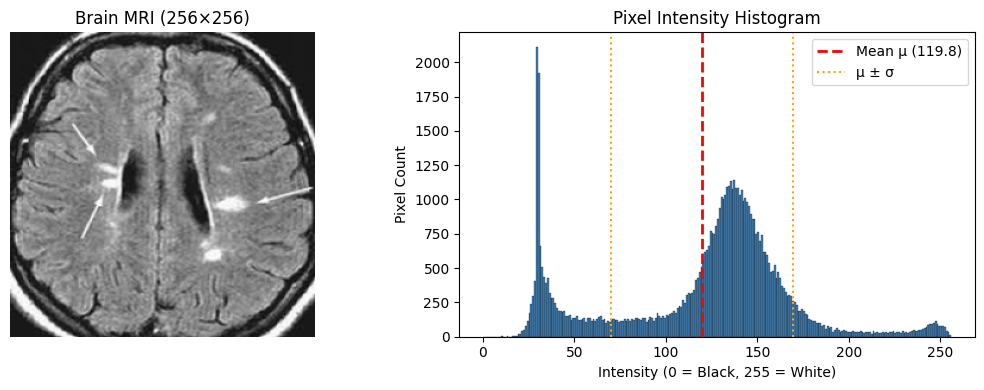

In [2]:
# Step 2: Grayscale Representation & Intensity Statistics
mri_raw = cv2.imread(PRIMARY_IMG_PATH, cv2.IMREAD_GRAYSCALE)

# Standardize to 256x256 for consistent spatial analysis
mri_gray = cv2.resize(mri_raw, (256, 256), interpolation=cv2.INTER_AREA)

mean_val = np.mean(mri_gray)
std_val  = np.std(mri_gray)
min_val  = np.min(mri_gray)
max_val  = np.max(mri_gray)

print("=" * 45)
print(f"Image File:          {os.path.basename(PRIMARY_IMG_PATH)}")
print(f"Dimensions:          {mri_gray.shape[0]} × {mri_gray.shape[1]} pixels (2D uint8)")
print(f"Intensity Range:     Min = {min_val}, Max = {max_val}")
print(f"Mean (μ):            {mean_val:.2f}")
print(f"Standard Dev (σ):    {std_val:.2f} (Contrast)")
print("=" * 45)

# Visual: Image + Histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.imshow(mri_gray, cmap='gray')
ax1.set_title(f"Brain MRI ({mri_gray.shape[0]}×{mri_gray.shape[1]})")
ax1.axis('off')

ax2.hist(mri_gray.ravel(), bins=256, range=[0, 256], color='steelblue', edgecolor='black', linewidth=0.2)
ax2.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean μ ({mean_val:.1f})")
ax2.axvline(mean_val + std_val, color='orange', linestyle=':', label=f"μ ± σ")
ax2.axvline(mean_val - std_val, color='orange', linestyle=':')
ax2.set_title("Pixel Intensity Histogram")
ax2.set_xlabel("Intensity (0 = Black, 255 = White)")
ax2.set_ylabel("Pixel Count")
ax2.legend()
plt.tight_layout()
plt.show()


---
## 🌓 Step 3: Thresholding & Binary Mask Generation

We apply **Otsu's Thresholding**, which automatically calculates the optimal threshold $T^*$ by maximizing between-class variance between the dark background air and bright brain tissue.

$$g(x, y) = \begin{cases} 255 & \text{if } f(x, y) \ge T^* \quad \text{(Brain Tissue / Foreground)} \\ 0 & \text{if } f(x, y) < T^* \quad \text{(Background Air Void)} \end{cases}$$

> *Note: This binary mask is a simple educational demonstration mask, not a clinical segmentation.*


✓ Otsu Optimal Threshold (T*): 95.0
✓ Foreground Pixels: 48,971 (74.7%)


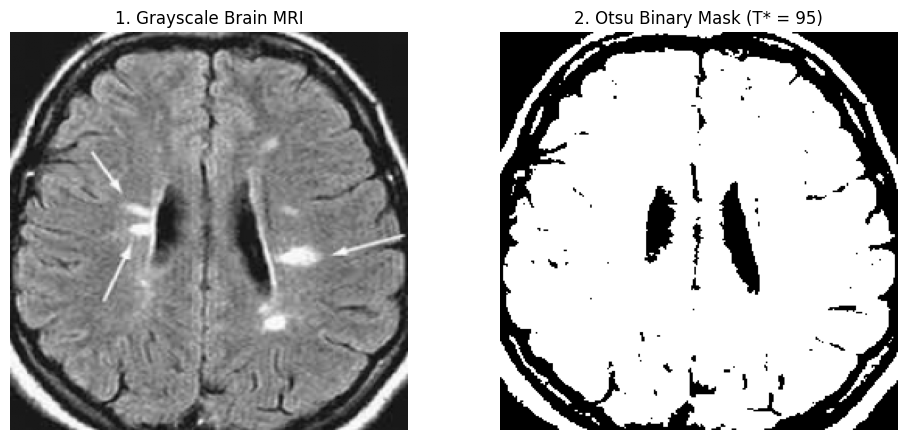

In [3]:
# Step 3: Otsu Automatic Binarization
otsu_thresh, binary_mask = cv2.threshold(mri_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"✓ Otsu Optimal Threshold (T*): {otsu_thresh:.1f}")
print(f"✓ Foreground Pixels: {np.sum(binary_mask == 255):,} ({(np.sum(binary_mask == 255)/binary_mask.size)*100:.1f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
ax1.imshow(mri_gray, cmap='gray')
ax1.set_title("1. Grayscale Brain MRI")
ax1.axis('off')

ax2.imshow(binary_mask, cmap='gray')
ax2.set_title(f"2. Otsu Binary Mask (T* = {otsu_thresh:.0f})")
ax2.axis('off')
plt.tight_layout()
plt.show()


---
## 🧩 Step 4: Structuring Elements (Kernels)

A **Structuring Element (SE)** $B$ is a small matrix that defines the pixel neighborhood evaluated during morphological operations.
- **Rectangular**: Evaluates an 8-connected square grid.
- **Elliptical**: Approximates a smooth circular disk (avoids square directional artifacts).
- **Cross**: Evaluates a 4-connected cardinal neighborhood.


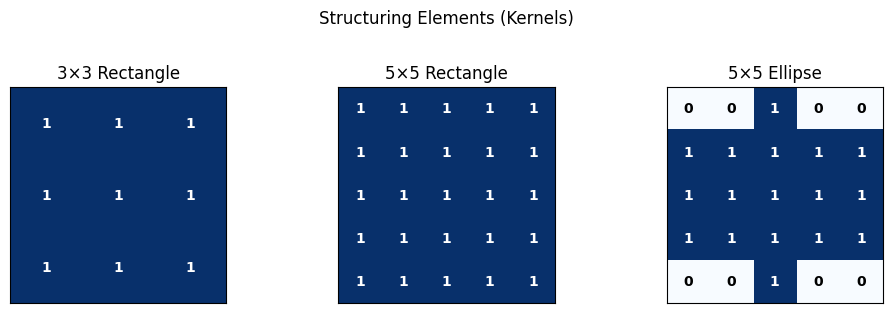

In [4]:
# Step 4: Structuring Elements Formulation
se_rect_3x3  = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
se_rect_5x5  = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
se_ellipse_5x5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

kernels = [
    ("3×3 Rectangle", se_rect_3x3),
    ("5×5 Rectangle", se_rect_5x5),
    ("5×5 Ellipse", se_ellipse_5x5)
]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, (name, k) in zip(axes, kernels):
    ax.imshow(k, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(name)
    for r in range(k.shape[0]):
        for c in range(k.shape[1]):
            ax.text(c, r, str(k[r, c]), ha='center', va='center',
                    color='white' if k[r, c] == 1 else 'black', fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Structuring Elements (Kernels)", fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


---
## ⚙️ Step 5: Core Operations (Erosion, Dilation, Opening, Closing)

1. **Erosion ($A \ominus B$)**: Tests where $B$ fits entirely inside foreground $A$. **Shrinks foreground** and strips boundary pixels.
2. **Dilation ($A \oplus B$)**: Tests where $B$ intersects foreground $A$. **Expands foreground** and bridges narrow gaps.
3. **Opening ($A \circ B = (A \ominus B) \oplus B$)**: Erosion followed by Dilation. **Removes small noise specks/spurs** while preserving overall shape.
4. **Closing ($A \bullet B = (A \oplus B) \ominus B$)**: Dilation followed by Erosion. **Fills small interior holes and cracks**.


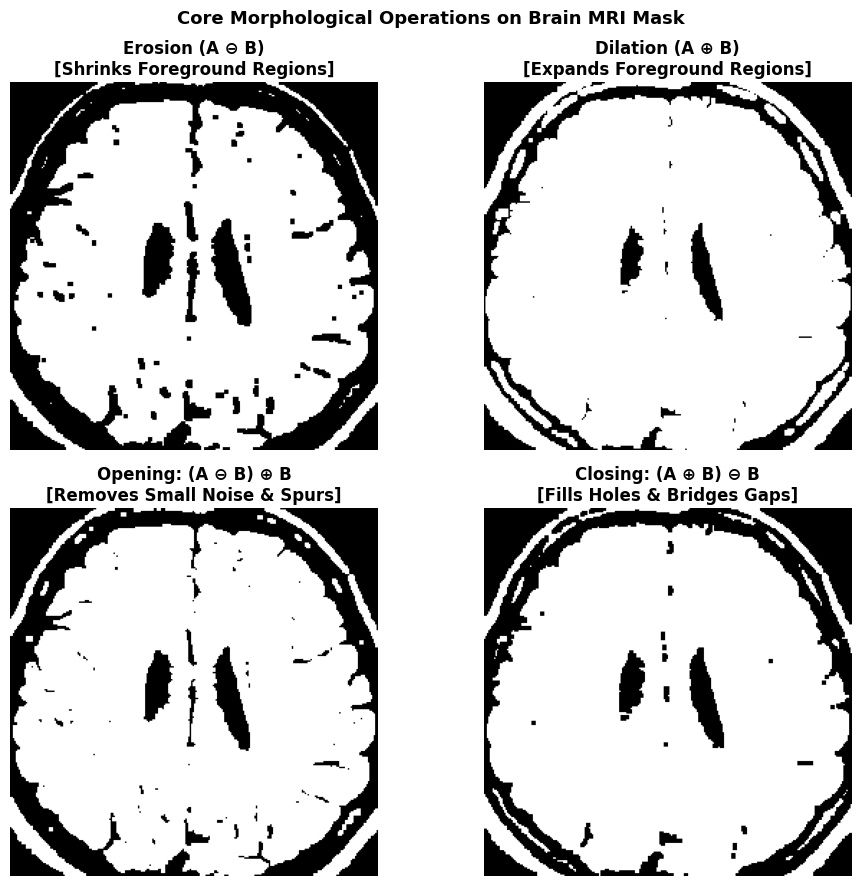

In [5]:
# Step 5: Execute Core Morphological Operations (3x3 Kernel)
eroded  = cv2.erode(binary_mask, se_rect_3x3, iterations=1)
dilated = cv2.dilate(binary_mask, se_rect_3x3, iterations=1)
opened  = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, se_rect_3x3)
closed  = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, se_rect_3x3)

# 2x2 Clean Comparison Grid
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

axes[0, 0].imshow(eroded, cmap='gray')
axes[0, 0].set_title("Erosion (A ⊖ B)\n[Shrinks Foreground Regions]", fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(dilated, cmap='gray')
axes[0, 1].set_title("Dilation (A ⊕ B)\n[Expands Foreground Regions]", fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(opened, cmap='gray')
axes[1, 0].set_title("Opening: (A ⊖ B) ⊕ B\n[Removes Small Noise & Spurs]", fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(closed, cmap='gray')
axes[1, 1].set_title("Closing: (A ⊕ B) ⊖ B\n[Fills Holes & Bridges Gaps]", fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle("Core Morphological Operations on Brain MRI Mask", fontsize=13, y=0.98, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🔬 Step 6: Structuring Element Experiment (Size & Shape Comparison)

- **Size Comparison ($3\times3$ vs $5\times5$ vs $7\times7$)**: Larger structuring elements inspect a broader neighborhood, resulting in stronger structural alteration.
- **Shape Comparison (Rectangle vs Ellipse)**: Elliptical kernels preserve natural curved anatomical contours, whereas rectangular kernels introduce blocky 90° corners.


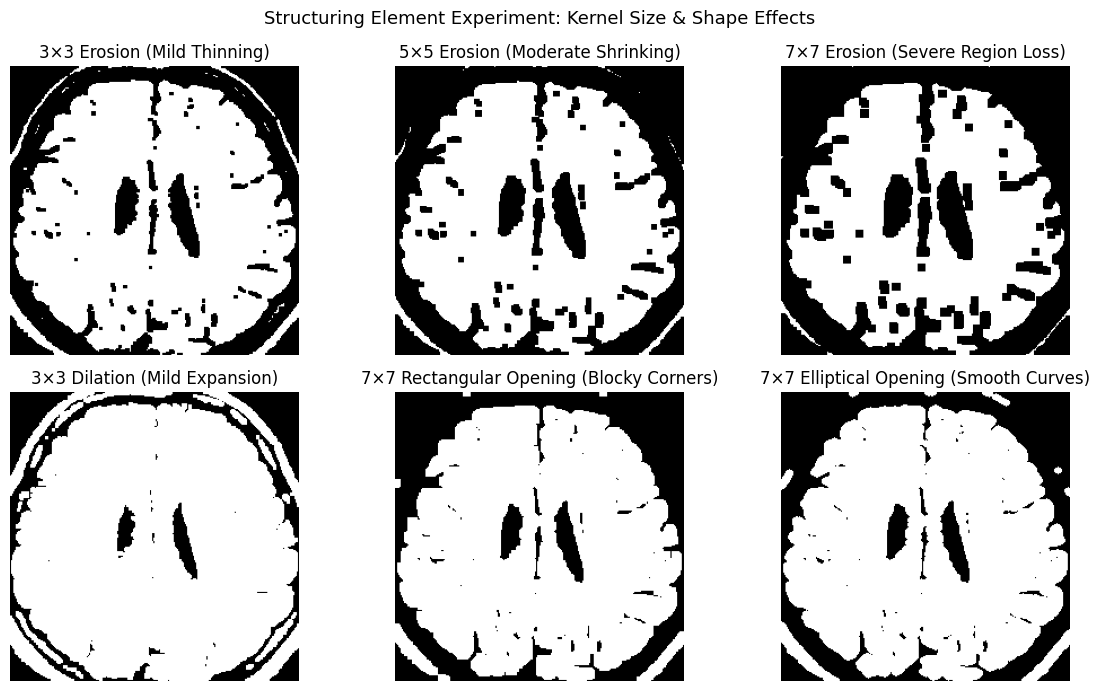

In [6]:
# Step 6: Kernel Size & Shape Experiments
k3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
k5 = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
k7 = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
k_ell = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

# Row 1: Kernel Size effect on Erosion
axes[0, 0].imshow(cv2.erode(binary_mask, k3), cmap='gray')
axes[0, 0].set_title("3×3 Erosion (Mild Thinning)")
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.erode(binary_mask, k5), cmap='gray')
axes[0, 1].set_title("5×5 Erosion (Moderate Shrinking)")
axes[0, 1].axis('off')

axes[0, 2].imshow(cv2.erode(binary_mask, k7), cmap='gray')
axes[0, 2].set_title("7×7 Erosion (Severe Region Loss)")
axes[0, 2].axis('off')

# Row 2: Kernel Size & Shape effect on Dilation / Opening
axes[1, 0].imshow(cv2.dilate(binary_mask, k3), cmap='gray')
axes[1, 0].set_title("3×3 Dilation (Mild Expansion)")
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, k7), cmap='gray')
axes[1, 1].set_title("7×7 Rectangular Opening (Blocky Corners)")
axes[1, 1].axis('off')

axes[1, 2].imshow(cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, k_ell), cmap='gray')
axes[1, 2].set_title("7×7 Elliptical Opening (Smooth Curves)")
axes[1, 2].axis('off')

plt.suptitle("Structuring Element Experiment: Kernel Size & Shape Effects", fontsize=13, y=0.98)
plt.tight_layout()
plt.show()


---
## 📐 Step 7: Morphological Boundary Extraction

The **Internal Boundary** $\beta(A)$ is obtained by subtracting the eroded mask from the original binary mask:

$$\beta(A) = A - (A \ominus B)$$


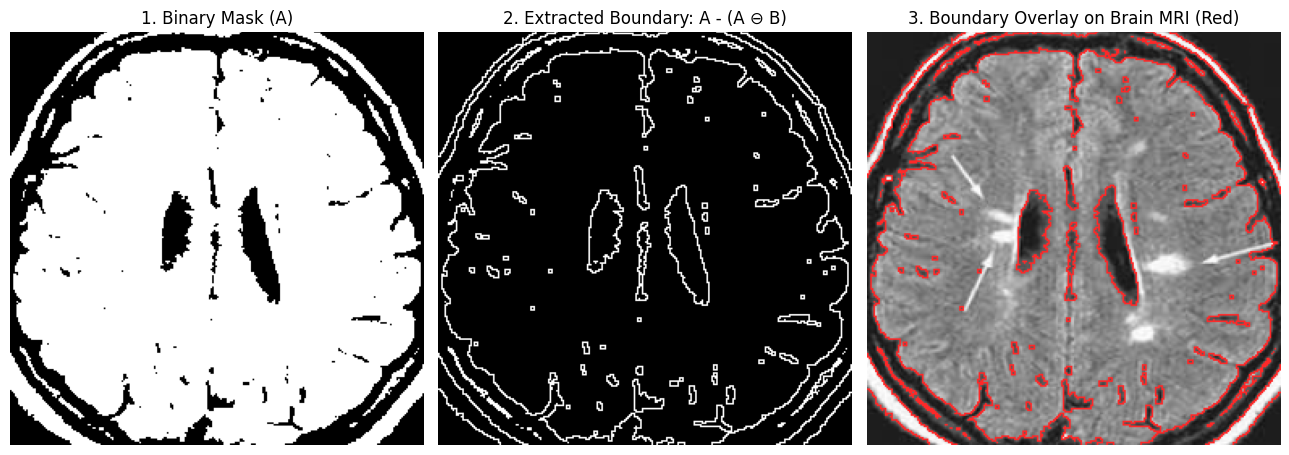

In [7]:
# Step 7: Morphological Boundary Extraction & Anatomical Overlay
boundary = cv2.subtract(binary_mask, eroded)

# Create color overlay on original grayscale MRI
mri_overlay = cv2.cvtColor(mri_gray, cv2.COLOR_GRAY2RGB)
mri_overlay[boundary == 255] = [255, 40, 40]  # Bright red boundary overlay

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 4.5))

ax1.imshow(binary_mask, cmap='gray')
ax1.set_title("1. Binary Mask (A)")
ax1.axis('off')

ax2.imshow(boundary, cmap='gray')
ax2.set_title("2. Extracted Boundary: A - (A ⊖ B)")
ax2.axis('off')

ax3.imshow(mri_overlay)
ax3.set_title("3. Boundary Overlay on Brain MRI (Red)")
ax3.axis('off')

plt.tight_layout()
plt.show()


---
## 🔄 Step 8: Multi-Slice Demonstration (All 5 Images)

Demonstrating that the morphological pipeline executes consistently across all 5 brain MRI images in the dataset.


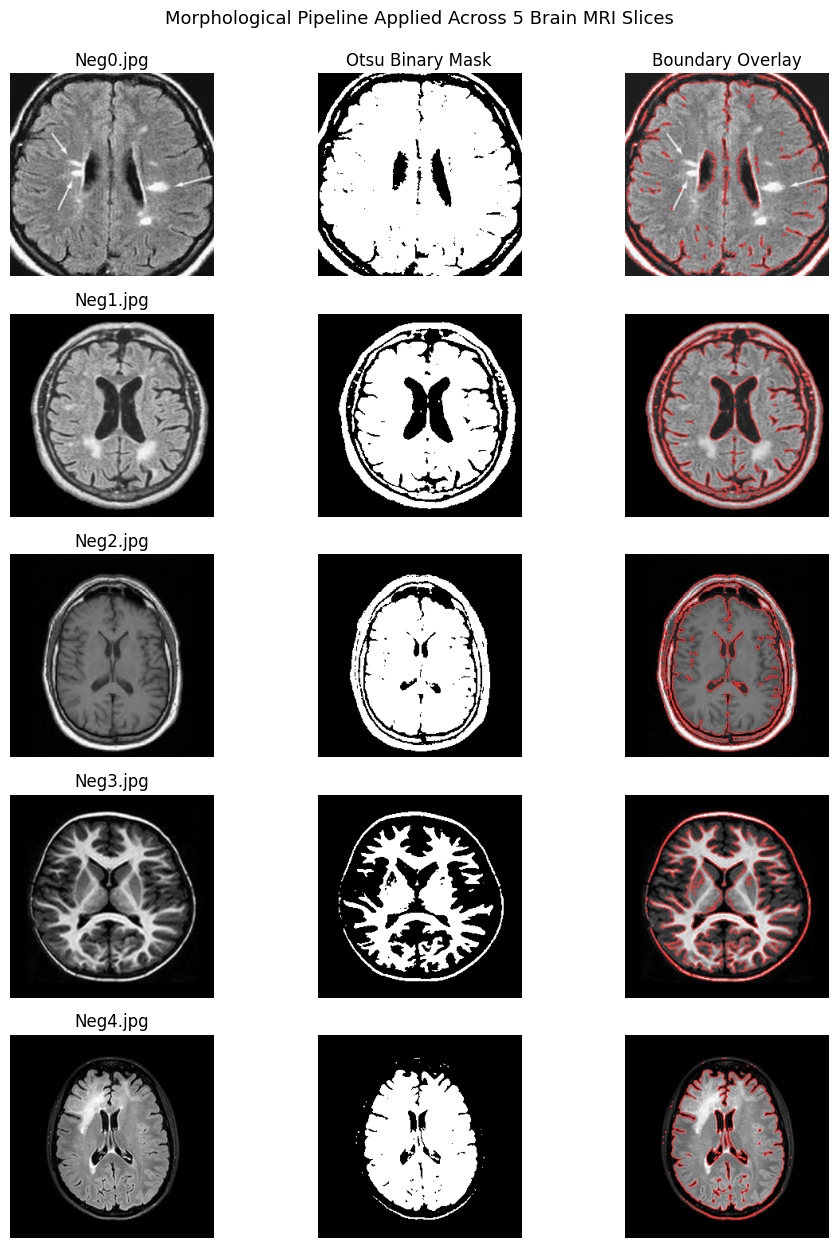

In [8]:
# Step 8: Process All 5 Brain MRI Images
fig, axes = plt.subplots(len(image_paths), 3, figsize=(10, 2.5 * len(image_paths)))

for i, p in enumerate(image_paths):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    img_res = cv2.resize(img, (256, 256))

    # Otsu thresholding
    _, b_mask = cv2.threshold(img_res, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Boundary Extraction
    b_eroded = cv2.erode(b_mask, se_rect_3x3)
    b_edge = cv2.subtract(b_mask, b_eroded)

    # Red overlay
    rgb_view = cv2.cvtColor(img_res, cv2.COLOR_GRAY2RGB)
    rgb_view[b_edge == 255] = [255, 50, 50]

    axes[i, 0].imshow(img_res, cmap='gray')
    axes[i, 0].set_title(f"{os.path.basename(p)}" if i == 0 else f"{os.path.basename(p)}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(b_mask, cmap='gray')
    axes[i, 1].set_title("Otsu Binary Mask" if i == 0 else "")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(rgb_view)
    axes[i, 2].set_title("Boundary Overlay" if i == 0 else "")
    axes[i, 2].axis('off')

plt.suptitle("Morphological Pipeline Applied Across 5 Brain MRI Slices", fontsize=13, y=0.995)
plt.tight_layout()
plt.show()


---
## 🏆 Step 9: Master Final Comparison Figure

Comprehensive summary visualization comparing the input MRI, binary mask, all 4 morphological operations, and the extracted boundary overlay.


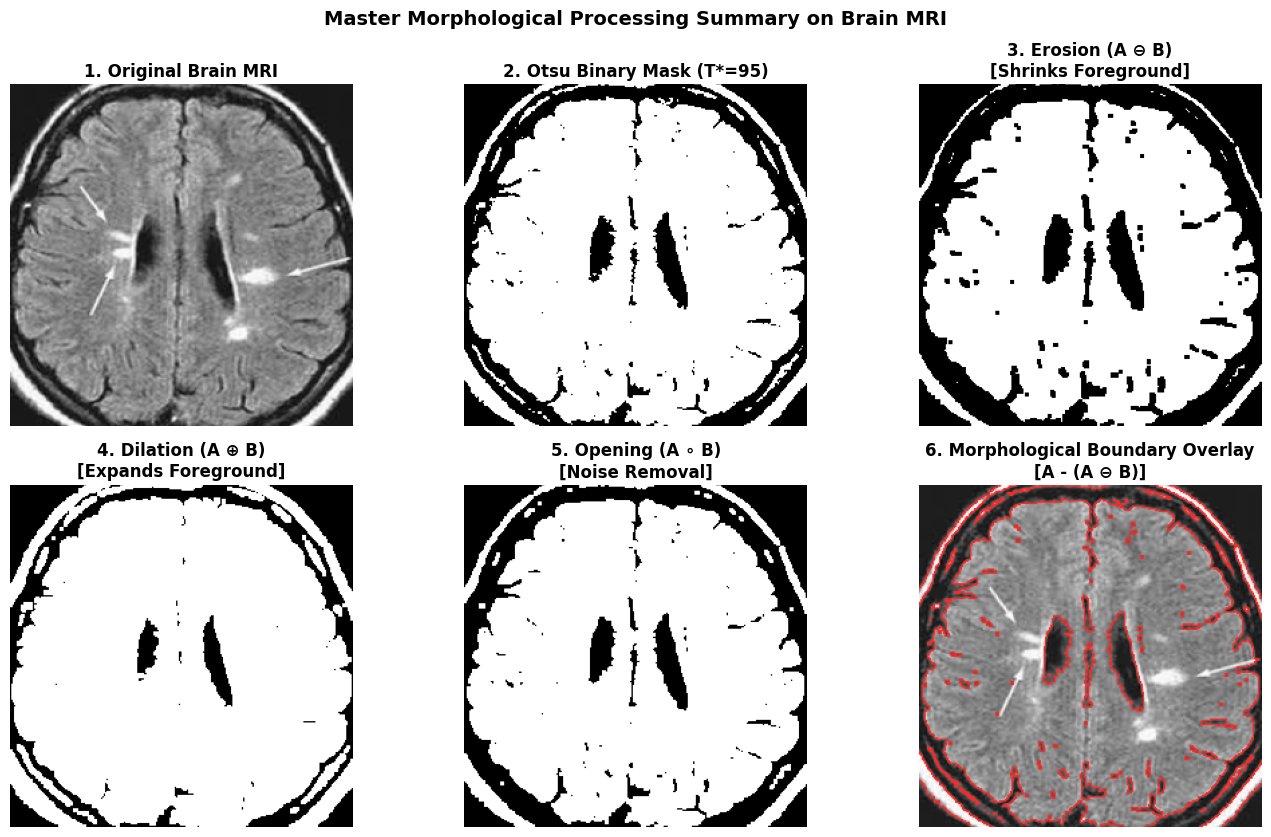

In [9]:
# Step 9: Master Final Comparison Summary
fig, axes = plt.subplots(2, 3, figsize=(14, 8.5))

axes[0, 0].imshow(mri_gray, cmap='gray')
axes[0, 0].set_title("1. Original Brain MRI", fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(binary_mask, cmap='gray')
axes[0, 1].set_title(f"2. Otsu Binary Mask (T*={otsu_thresh:.0f})", fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(eroded, cmap='gray')
axes[0, 2].set_title("3. Erosion (A ⊖ B)\n[Shrinks Foreground]", fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(dilated, cmap='gray')
axes[1, 0].set_title("4. Dilation (A ⊕ B)\n[Expands Foreground]", fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(opened, cmap='gray')
axes[1, 1].set_title("5. Opening (A ∘ B)\n[Noise Removal]", fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(mri_overlay)
axes[1, 2].set_title("6. Morphological Boundary Overlay\n[A - (A ⊖ B)]", fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle("Master Morphological Processing Summary on Brain MRI", fontsize=14, y=0.98, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 📝 Summary of Observations

| Operation | Formula | Geometric Effect | Visual Effect on Brain MRI |
| :--- | :--- | :--- | :--- |
| **Otsu Threshold** | $f(x,y) \ge T^*$ | Intensity Binarization | Separates brain parenchyma from background void. |
| **Erosion** | $A \ominus B$ | Shrinks Foreground | Thins cortex perimeter and strips outer boundary pixels. |
| **Dilation** | $A \oplus B$ | Expands Foreground | Bridges narrow fissures and enlarges tissue regions. |
| **Opening** | $(A \ominus B) \oplus B$ | Noise Removal | Cleans stray background speckles without shrinking brain volume. |
| **Closing** | $(A \oplus B) \ominus B$ | Hole Filling | Seals internal dark voids/cavities within brain mask. |
| **Boundary** | $A - (A \ominus B)$ | Perimeter Extraction | Extracts clean 1-pixel outer tissue boundary. |

---

## 🗣️ How the Project Works (10-Step Presentation Walkthrough)

Use these **10 simple steps** to explain the project in class:
1. **Load Brain MRI**: Read 2D MRI slice from Google Drive or local folder as a grayscale matrix ($H \times W$, `uint8`).
2. **Compute Statistics**: Calculate mean ($\mu$), standard deviation ($\sigma$, contrast), and histogram.
3. **Binarize via Otsu**: Automatically find optimal threshold $T^*$ separating tissue from background.
4. **Create Structuring Element**: Construct $3\times3$ and $5\times5$ kernels defining the neighborhood.
5. **Apply Erosion**: Shrink foreground to strip boundary pixels and eliminate thin spurs.
6. **Apply Dilation**: Expand foreground to bridge small disconnected tissue gaps.
7. **Apply Opening**: Combine Erosion $\rightarrow$ Dilation to remove isolated noise particles.
8. **Apply Closing**: Combine Dilation $\rightarrow$ Erosion to seal internal holes and cracks.
9. **Extract Boundary**: Subtract eroded mask from binary mask to isolate perimeter and overlay in red.
10. **Validate Across Slices**: Run the pipeline across all 5 images and compare kernel sizes.

---

## 🎓 15 Viva Voce Questions & Crisp Answers

1. **Q: What is morphological image processing?**  
   *A:* A non-linear framework based on set theory that analyzes and modifies geometric shapes using a structuring element.
2. **Q: What is a structuring element?**  
   *A:* A small binary matrix with a defined origin (center pixel) that defines the neighborhood examined during an operation.
3. **Q: What is the difference between erosion and dilation?**  
   *A:* Erosion shrinks foreground ($B_z \subseteq A$), while dilation expands foreground ($(B^s)_z \cap A \neq \emptyset$).
4. **Q: Why convert grayscale MRI to binary first?**  
   *A:* Binary masks separate regions into clear foreground (tissue) and background (void), enabling set-theoretic operations.
5. **Q: What is morphological opening?**  
   *A:* Erosion followed by dilation ($(A \ominus B) \oplus B$). It removes small noise specks without reducing object size.
6. **Q: What is morphological closing?**  
   *A:* Dilation followed by erosion ($(A \oplus B) \ominus B$). It fills small holes and bridges gaps.
7. **Q: What is idempotency?**  
   *A:* Applying opening or closing multiple times yields the same result as applying it once: $(A \circ B) \circ B = A \circ B$.
8. **Q: How does Otsu's thresholding work?**  
   *A:* It automatically finds the threshold that maximizes the between-class variance between foreground and background.
9. **Q: How is the internal boundary extracted?**  
   *A:* By subtracting the eroded mask from the binary mask: $\beta(A) = A - (A \ominus B)$.
10. **Q: What happens when structuring element size increases?**  
    *A:* Larger kernels evaluate larger neighborhoods, producing more aggressive shrinking (erosion) or expansion (dilation).
11. **Q: Why use elliptical kernels for medical images?**  
    *A:* Elliptical kernels produce smooth, isotropic contours, avoiding the blocky square corners of rectangular kernels.
12. **Q: What is the duality property?**  
    *A:* Eroding the foreground is mathematically equivalent to dilating the background: $(A \ominus B)^c = A^c \oplus B^s$.
13. **Q: Why is morphology useful in medical imaging?**  
    *A:* It fast, explainable, removes noise, cleans thresholded masks, and extracts organ perimeters without training data.
14. **Q: Why are ML/DL models not used here?**  
    *A:* Unit-I focuses on foundational classical image processing, which is deterministic, simple, and fully explainable.
15. **Q: Is this a clinical diagnostic tool?**  
    *A:* No. This is strictly an educational demonstration. Clinical diagnosis requires certified algorithms and medical validation.
